# Notebook 00c — H3 Hex-Grid Binning

## Hexagonal Cell Aggregation as a Location Privacy Technique

H3 hex-grid binning is a spatial aggregation approach to location privacy:
each GPS coordinate is snapped to the centroid of an H3 hexagonal cell at a
chosen resolution. Multiple locations within the same cell share an identical
masked coordinate, providing a form of spatial k-anonymity. This notebook
applies H3 binning at resolutions 7, 8, and 9 to the 250 John Snow cholera
death locations, visualises cell boundaries on a Folium map, and compares the
utility-privacy tradeoff across resolutions.

**Three-part structure:**

- **Part 1** — H3 binning at resolution 9: cell assignment, centroids, Folium map
- **Part 2** — Multi-resolution comparison (resolutions 7-9) around Broadwick Street
- **Part 3** — Utility-privacy tradeoff: EDD, unique cells, and spatial k-anonymity


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import h3

from geoprivacy.hexgrid import get_h3_address, visualize_hexagons
from map_encryption import haversine_m
from map_encryption.viz import show_md_table


---
## 00c.1  H3 Binning at Resolution 9

At resolution 9, the average H3 hexagonal cell has an edge length of ~174 m and
an area of ~0.105 km^2. Each cholera death location is assigned to its containing
cell; the cell centroid becomes the masked coordinate. Records that fall within the
same cell are indistinguishable in the masked dataset.


In [2]:
df = pd.read_csv('data/cholera_deaths.csv')
pumps = pd.read_csv('data/pumps.csv')

RES = 9

df['h3_cell'] = df.apply(lambda r: h3.latlng_to_cell(r.LAT, r.LON, RES), axis=1)
df['masked_lat'] = df['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[0])
df['masked_lon'] = df['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[1])

n_cells = df['h3_cell'].nunique()
cell_area = h3.cell_area(df['h3_cell'].iloc[0], unit='km^2')
print(f'Resolution {RES}: {len(df)} records assigned to {n_cells} unique cells')
print(f'Average cell area: {cell_area:.4f} km^2')
print(f'Records per cell (mean): {len(df)/n_cells:.1f}')


Resolution 9: 250 records assigned to 5 unique cells
Average cell area: 0.0942 km^2
Records per cell (mean): 50.0


---
## 00c.2  Folium Map — H3 Cell Boundaries at Resolution 9


In [3]:
unique_cells = df['h3_cell'].unique().tolist()

m = folium.Map(location=[51.5134, -0.1365], zoom_start=15, tiles='cartodbpositron')

m = visualize_hexagons(unique_cells, color='#1f77b4', folium_map=m)

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row.masked_lat, row.masked_lon],
        radius=2, color='#ff7f0e', fill=True, fill_opacity=0.8,
        tooltip=f'Cell centroid (Deaths: {row.DEATHS})'
    ).add_to(m)
    folium.CircleMarker(
        location=[row.LAT, row.LON],
        radius=1, color='#aec7e8', fill=True, fill_opacity=0.4,
        tooltip='Original'
    ).add_to(m)

for _, row in pumps.iterrows():
    folium.Marker(
        location=[row.LAT, row.LON],
        icon=folium.Icon(color='red', icon='tint', prefix='fa'),
        tooltip=row.Street
    ).add_to(m)
m


**Figure 00c-1** — H3 hexagonal cell boundaries (blue) at resolution 9 containing the
250 cholera death locations. Orange dots mark cell centroids (masked positions); pale
blue dots show original locations. Multiple original locations within the same cell
collapse to a single centroid — the cell provides spatial k-anonymity with k equal to
the count of records in that cell.


---
## 00c.3  Multi-Resolution Privacy at Broadwick Street

The Broadwick Street pump is the epidemic's central location. At lower resolutions
(coarser cells), all deaths within a larger area collapse to the same centroid,
providing stronger anonymity at the cost of greater positional error.


In [4]:
BROADWICK = (51.513341, -0.136668)

print(f'{"Res":>4}  {"Cell ID":>20}  {"Centroid":>30}  {"Area (km^2)":>12}  {"Edge (m)":>10}')
print('-' * 90)
for res in [7, 8, 9]:
    cell = h3.latlng_to_cell(BROADWICK[0], BROADWICK[1], res)
    clat, clon = h3.cell_to_latlng(cell)
    area = h3.cell_area(cell, unit='km^2')
    edge_m = (area * 1e6 / (3 * 3**0.5 / 2)) ** 0.5  # edge from area of regular hexagon
    print(f'{res:>4}  {cell:>20}  ({clat:.5f}, {clon:.6f})  {area:>12.4f}  {edge_m:>10.0f}')


 Res               Cell ID                        Centroid   Area (km^2)    Edge (m)
------------------------------------------------------------------------------------------
   7       87195da49ffffff  (51.50971, -0.142520)        4.6155        1333
   8       88195da499fffff  (51.51538, -0.134587)        0.6592         504
   9       89195da498fffff  (51.51266, -0.136245)        0.0942         190


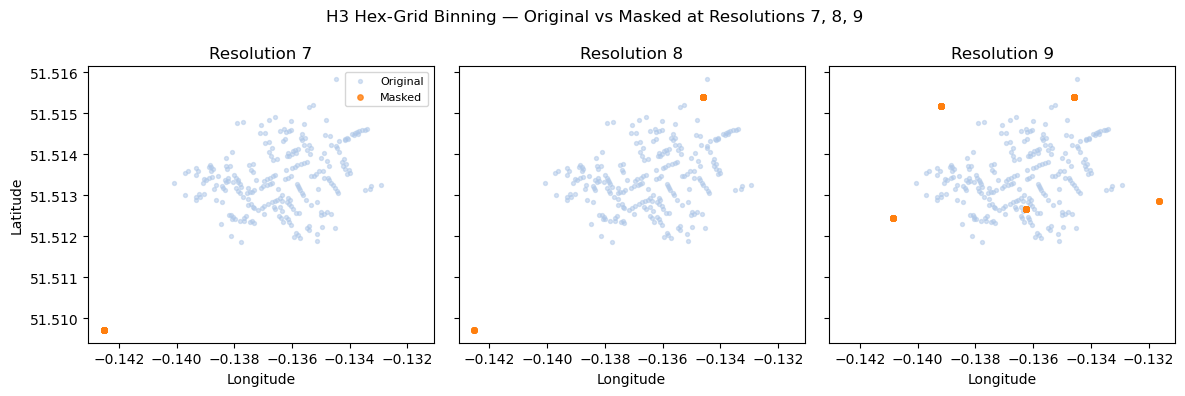

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
lats = df.LAT.values
lons = df.LON.values

for ax, res in zip(axes, [7, 8, 9]):
    clats = [h3.cell_to_latlng(h3.latlng_to_cell(la, lo, res))[0]
             for la, lo in zip(lats, lons)]
    clons = [h3.cell_to_latlng(h3.latlng_to_cell(la, lo, res))[1]
             for la, lo in zip(lats, lons)]
    ax.scatter(lons, lats, s=8, color='#aec7e8', alpha=0.5, label='Original')
    ax.scatter(clons, clats, s=15, color='#ff7f0e', alpha=0.8, label='Masked')
    ax.set_title(f'Resolution {res}')
    ax.set_xlabel('Longitude')
    if ax == axes[0]:
        ax.set_ylabel('Latitude')

axes[0].legend(fontsize=8)
fig.suptitle('H3 Hex-Grid Binning — Original vs Masked at Resolutions 7, 8, 9')
plt.tight_layout()
plt.show()


**Figure 00c-2** — Original locations (pale blue) vs H3 cell centroids (orange) at
resolutions 7, 8, and 9. At resolution 7 (coarsest), nearly all Soho deaths collapse
to one or two cell centroids — maximum anonymity, minimum utility. At resolution 9
(finest), cells are ~174 m wide and preserve more spatial structure.


---
## 00c.4  Utility-Privacy Tradeoff across Resolutions


In [6]:
rows = []
orig_coords = list(zip(df.LAT, df.LON))

for res in [7, 8, 9]:
    cells_r = [h3.latlng_to_cell(la, lo, res) for la, lo in orig_coords]
    masked_coords = [h3.cell_to_latlng(c) for c in cells_r]

    edd = np.mean([haversine_m(ot[0], ot[1], mt[0], mt[1])
                   for ot, mt in zip(orig_coords, masked_coords)])

    n_unique = len(set(cells_r))
    k_min = pd.Series(cells_r).value_counts().min()
    k_mean = pd.Series(cells_r).value_counts().mean()

    rows.append({
        'Resolution': res,
        'Unique cells': n_unique,
        'Mean EDD (m)': f'{edd:.0f}',
        'Min k (spatial)': k_min,
        'Mean k (spatial)': f'{k_mean:.1f}',
    })

tradeoff_df = pd.DataFrame(rows)
show_md_table(tradeoff_df, 'Table 00c-1 -- H3 hex-grid binning: resolution vs privacy-utility tradeoff')


**Table 00c-1 -- H3 hex-grid binning: resolution vs privacy-utility tradeoff**

| Resolution | Unique cells | Mean EDD (m) | Min k (spatial) | Mean k (spatial) |
| --- | --- | --- | --- | --- |
| 7 | 1 | 597 | 250 | 250.0 |
| 8 | 2 | 270 | 7 | 125.0 |
| 9 | 5 | 115 | 7 | 50.0 |

**Table 00c-1** — At resolution 7 (coarsest), all 250 records collapse into only a few
cells (very high k, very high EDD). At resolution 9, cells are smaller: more unique cells,
lower k, lower displacement. The full cryptographic pipeline (NB01-NB17) achieves ~35 m EDD
and ~0% re-identification without the k-anonymity trade-off — individual precision is preserved
for authorised decode-tier holders but appears globally random to anyone without keys.
